Вариант 3: набор данных №3, классификаторы: 1 – линейная регрессия без использования регуляризаторов; 3 – линейная регрессия, RIDGE регуляризатор.

Аннотация: содержит ответы газового мультисенсорного устройства, развернутого на местах в итальянском городе. 

Информация о наборе данных:

Набор данных содержит 9358 экземпляров почасовых усредненных ответов из массива 5 химических датчиков оксида металла, встроенных в химическое мультисенсорное устройство качества воздуха. Устройство было расположено на поле в значительно загрязненном районе, на дороге, в итальянском городе. Данные были зарегистрированы с марта 2004 года по февраль 2005 года (один год), представляющие самые длинные свободно доступные записи ответов на полевые приборы качества воздуха химических датчиков. Наземная истина почасовой усредненной концентрации для CO, не метановых углеводородов, бензола, общих оксидов азота (NOx) и диоксида азота (NO2) и были предоставлены совместным эталонным сертифицированным анализатором.

Доказательства поперечной чувствительности, а также как концепция, так и датчики присутствуют, как описано в De Vito et al., Sens. И Act. B, Vol. 129,2,2008 (требуется цитирование) в конечном итоге влияет на возможности оценки концентрации датчиков. Отсутствующие значения помечены значением -200.

Номер. Признак - пояснение:

0. Date (DD/MM/YYYY) - Дата в формате День/Месяц/Год.

1. Time (HH.MM.SS) - Время в формате Часы:Минуты:Секунды.

2. True hourly average CO concentration (mg/m³) - Истинная среднечасовая концентрация угарного газа (CO) в миллиграммах на кубический метр (измерена эталонным анализатором).

3. PT08.S1 (tin oxide) hourly averaged sensor response (nominally CO targeted) - Среднечасовой отклик датчика на основе оксида олова (SnO₂), предназначенного для измерения CO (косвенный показатель).

4. True hourly averaged Non-Methane Hydrocarbons (NMHC) concentration (µg/m³) - Истинная среднечасовая концентрация неметановых углеводородов (NMHC) в микрограммах на кубический метр.

5. True hourly averaged Benzene concentration (µg/m³) - Истинная среднечасовая концентрация бензола (C₆H₆) в микрограммах на кубический метр.

6. PT08.S2 (titania) hourly averaged sensor response (nominally NMHC targeted) - Среднечасовой отклик датчика на основе диоксида титана (TiO₂), предназначенного для измерения NMHC.

7. True hourly averaged NOx concentration (ppb) - Истинная среднечасовая концентрация оксидов азота (NOx) в частях на миллиард (ppb).

8. PT08.S3 (tungsten oxide) hourly averaged sensor response (nominally NOx targeted) - Среднечасовой отклик датчика на основе оксида вольфрама (WO₃), предназначенного для измерения NOx.

9. True hourly averaged NO₂ concentration (µg/m³) - Истинная среднечасовая концентрация диоксида азота (NO₂) в микрограммах на кубический метр.

10. PT08.S4 (tungsten oxide) hourly averaged sensor response (nominally NO₂ targeted) - Среднечасовой отклик датчика на основе оксида вольфрама (WO₃), предназначенного для измерения NO₂.

11. PT08.S5 (indium oxide) hourly averaged sensor response (nominally O₃ targeted) - Среднечасовой отклик датчика на основе оксида индия (In₂O₃), предназначенного для измерения озона (O₃).

12. Temperature (°C) - Температура воздуха в градусах Цельсия.

13. Relative Humidity (%) - Относительная влажность воздуха в процентах.

14. AH Absolute Humidity - Абсолютная влажность (количество водяного пара в воздухе).

In [5]:
import pandas as pd


data = pd.read_csv("AirQualityUCI.csv")

In [6]:
data.dtypes

Date;Time;CO(GT);PT08.S1(CO);NMHC(GT);C6H6(GT);PT08.S2(NMHC);NOx(GT);PT08.S3(NOx);NO2(GT);PT08.S4(NO2);PT08.S5(O3);T;RH;AH;;    object
dtype: object

In [7]:
# Правильное чтение файла
data_clen = pd.read_csv('AirQualityUCI.csv', delimiter=';')

# Удаление пустых колонок (на всякий)
data_clen = data_clen.loc[:, ~data_clen.columns.str.contains('^Unnamed')]

# Теперь проверяем типы
data_clen.dtypes

Date              object
Time              object
CO(GT)            object
PT08.S1(CO)      float64
NMHC(GT)         float64
C6H6(GT)          object
PT08.S2(NMHC)    float64
NOx(GT)          float64
PT08.S3(NOx)     float64
NO2(GT)          float64
PT08.S4(NO2)     float64
PT08.S5(O3)      float64
T                 object
RH                object
AH                object
dtype: object

Вот так то получше

In [8]:
data_cleaned=data_clen.copy()

# Размер до удаления дубликатов
original_shape = data_cleaned.shape
print(f"Размер данных ДО удаления дубликатов: {original_shape}")
print(f"Количество строк: {original_shape[0]}, столбцов: {original_shape[1]}")

# Удаляем дубликаты (полные копии строк)
data_cleaned = data_cleaned.drop_duplicates()

# Размер после удаления дубликатов
cleaned_shape = data_cleaned.shape
print(f"\nРазмер данных ПОСЛЕ удаления дубликатов: {cleaned_shape}")
print(f"Количество строк: {cleaned_shape[0]}, столбцов: {cleaned_shape[1]}")

# Сравнение
duplicates_removed = original_shape[0] - cleaned_shape[0]
print(f"\nУдалено дубликатов: {duplicates_removed}")
print(f"Процент дубликатов: {duplicates_removed/original_shape[0]*100:.2f}%")

Размер данных ДО удаления дубликатов: (9471, 15)
Количество строк: 9471, столбцов: 15

Размер данных ПОСЛЕ удаления дубликатов: (9358, 15)
Количество строк: 9358, столбцов: 15

Удалено дубликатов: 113
Процент дубликатов: 1.19%


In [9]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler


# Посмотрим что надо исправить
data_cleaned.head(10)

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,"2,6",1360.0,150.0,"11,9",1046.0,166.0,1056.0,113.0,1692.0,1268.0,"13,6","48,9","0,7578"
1,10/03/2004,19.00.00,2,1292.0,112.0,"9,4",955.0,103.0,1174.0,92.0,1559.0,972.0,"13,3","47,7","0,7255"
2,10/03/2004,20.00.00,"2,2",1402.0,88.0,"9,0",939.0,131.0,1140.0,114.0,1555.0,1074.0,"11,9","54,0","0,7502"
3,10/03/2004,21.00.00,"2,2",1376.0,80.0,"9,2",948.0,172.0,1092.0,122.0,1584.0,1203.0,"11,0","60,0","0,7867"
4,10/03/2004,22.00.00,"1,6",1272.0,51.0,"6,5",836.0,131.0,1205.0,116.0,1490.0,1110.0,"11,2","59,6","0,7888"
5,10/03/2004,23.00.00,"1,2",1197.0,38.0,"4,7",750.0,89.0,1337.0,96.0,1393.0,949.0,"11,2","59,2","0,7848"
6,11/03/2004,00.00.00,"1,2",1185.0,31.0,"3,6",690.0,62.0,1462.0,77.0,1333.0,733.0,"11,3","56,8","0,7603"
7,11/03/2004,01.00.00,1,1136.0,31.0,"3,3",672.0,62.0,1453.0,76.0,1333.0,730.0,"10,7","60,0","0,7702"
8,11/03/2004,02.00.00,"0,9",1094.0,24.0,"2,3",609.0,45.0,1579.0,60.0,1276.0,620.0,"10,7","59,7","0,7648"
9,11/03/2004,03.00.00,"0,6",1010.0,19.0,"1,7",561.0,-200.0,1705.0,-200.0,1235.0,501.0,"10,3","60,2","0,7517"


In [10]:
# 1. Преобразование числовых полей (замена запятых на точки)
num_cols_with_comma = ['CO(GT)', 'C6H6(GT)', 'T', 'RH', 'AH']
for col in num_cols_with_comma:
    if col in data_cleaned.columns:
        data_cleaned[col] = data_cleaned[col].astype(str).str.replace(',', '.').astype(float)
# Проверка
data_cleaned.dtypes

Date              object
Time              object
CO(GT)           float64
PT08.S1(CO)      float64
NMHC(GT)         float64
C6H6(GT)         float64
PT08.S2(NMHC)    float64
NOx(GT)          float64
PT08.S3(NOx)     float64
NO2(GT)          float64
PT08.S4(NO2)     float64
PT08.S5(O3)      float64
T                float64
RH               float64
AH               float64
dtype: object

In [11]:
data_cleaned_v1=data_cleaned.copy()
data_cleaned_v1.head(10)

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888
5,10/03/2004,23.00.00,1.2,1197.0,38.0,4.7,750.0,89.0,1337.0,96.0,1393.0,949.0,11.2,59.2,0.7848
6,11/03/2004,00.00.00,1.2,1185.0,31.0,3.6,690.0,62.0,1462.0,77.0,1333.0,733.0,11.3,56.8,0.7603
7,11/03/2004,01.00.00,1.0,1136.0,31.0,3.3,672.0,62.0,1453.0,76.0,1333.0,730.0,10.7,60.0,0.7702
8,11/03/2004,02.00.00,0.9,1094.0,24.0,2.3,609.0,45.0,1579.0,60.0,1276.0,620.0,10.7,59.7,0.7648
9,11/03/2004,03.00.00,0.6,1010.0,19.0,1.7,561.0,-200.0,1705.0,-200.0,1235.0,501.0,10.3,60.2,0.7517


In [12]:
import numpy as np


# 2. Замена -200 на NaN во всех числовых столбцах
numeric_cols = data_cleaned_v1.select_dtypes(include=['float64', 'int64']).columns
data_cleaned_v2=data_cleaned_v1.copy()
data_cleaned_v2[numeric_cols] = data_cleaned_v1[numeric_cols].replace(-200, np.nan)
data_cleaned_v2.head(10)

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888
5,10/03/2004,23.00.00,1.2,1197.0,38.0,4.7,750.0,89.0,1337.0,96.0,1393.0,949.0,11.2,59.2,0.7848
6,11/03/2004,00.00.00,1.2,1185.0,31.0,3.6,690.0,62.0,1462.0,77.0,1333.0,733.0,11.3,56.8,0.7603
7,11/03/2004,01.00.00,1.0,1136.0,31.0,3.3,672.0,62.0,1453.0,76.0,1333.0,730.0,10.7,60.0,0.7702
8,11/03/2004,02.00.00,0.9,1094.0,24.0,2.3,609.0,45.0,1579.0,60.0,1276.0,620.0,10.7,59.7,0.7648
9,11/03/2004,03.00.00,0.6,1010.0,19.0,1.7,561.0,NaN,1705.0,NaN,1235.0,501.0,10.3,60.2,0.7517



=== АНАЛИЗ ПРОПУЩЕННЫХ ЗНАЧЕНИЙ ===

ДО обработки:
Всего строк в data_cleaned_v2: 9358
Полностью пустых строк: 1

Пропуски по столбцам:
NMHC(GT)         8444
CO(GT)           1684
NO2(GT)          1643
NOx(GT)          1640
PT08.S1(CO)       367
C6H6(GT)          367
PT08.S2(NMHC)     367
PT08.S3(NOx)      367
PT08.S4(NO2)      367
PT08.S5(O3)       367
T                 367
RH                367
AH                367
Date                1
Time                1
dtype: int64


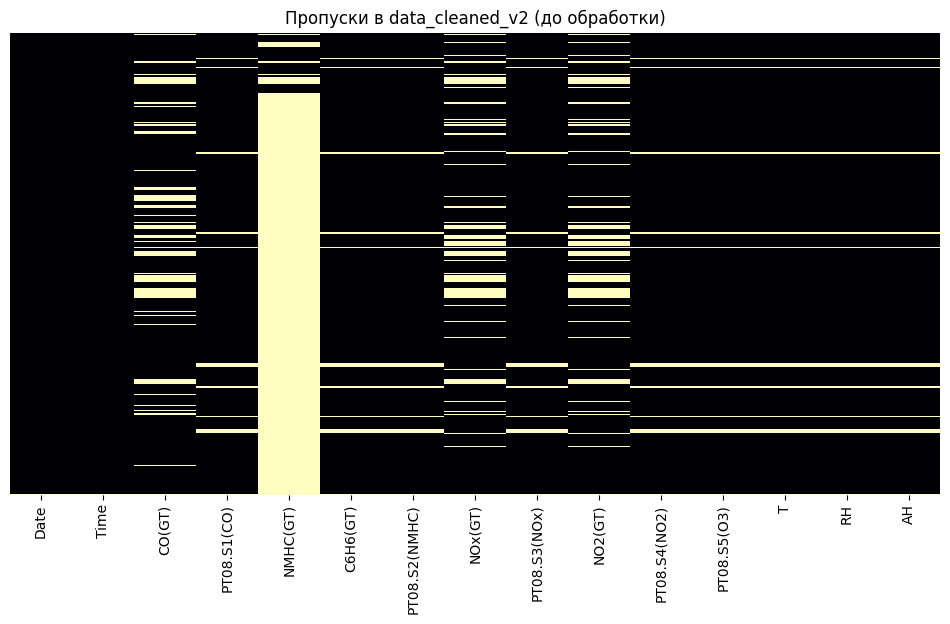


ПОСЛЕ удаления полностью пустых строк:
Удалено строк: 1
Осталось строк: 9357

Оставшиеся пропуски по столбцам:
NMHC(GT)         8443
CO(GT)           1683
NO2(GT)          1642
NOx(GT)          1639
PT08.S1(CO)       366
C6H6(GT)          366
PT08.S2(NMHC)     366
PT08.S3(NOx)      366
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
Date                0
Time                0
dtype: int64


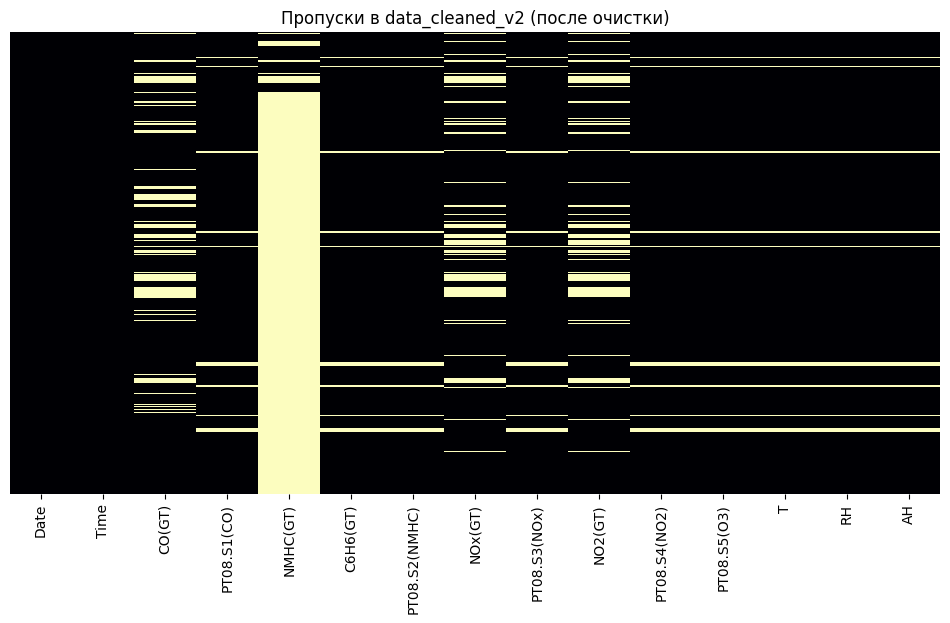


✔ Полностью пустых строк не осталось

Типы данных в data_cleaned_v2:
Date              object
Time              object
CO(GT)           float64
PT08.S1(CO)      float64
NMHC(GT)         float64
C6H6(GT)         float64
PT08.S2(NMHC)    float64
NOx(GT)          float64
PT08.S3(NOx)     float64
NO2(GT)          float64
PT08.S4(NO2)     float64
PT08.S5(O3)      float64
T                float64
RH               float64
AH               float64
dtype: object


In [13]:
import seaborn as sns


# 3. Анализ и обработка пропущенных значений в data_cleaned_v2
print("\n=== АНАЛИЗ ПРОПУЩЕННЫХ ЗНАЧЕНИЙ ===")

# Проверка перед обработкой
print("\nДО обработки:")
print(f"Всего строк в data_cleaned_v2: {len(data_cleaned_v2)}")
print(f"Полностью пустых строк: {data_cleaned_v2.isna().all(axis=1).sum()}")
print("\nПропуски по столбцам:")
print(data_cleaned_v2.isna().sum().sort_values(ascending=False))

# Визуализация пропусков до обработки
plt.figure(figsize=(12, 6))
sns.heatmap(data_cleaned_v2.isna(), yticklabels=False, cbar=False, cmap='magma')
plt.title('Пропуски в data_cleaned_v2 (до обработки)')
plt.show()

# Удаление полностью пустых строк
initial_count = len(data_cleaned_v2)
data_cleaned_v2 = data_cleaned_v2.dropna(how='all')

# Проверка после обработки
print("\nПОСЛЕ удаления полностью пустых строк:")
print(f"Удалено строк: {initial_count - len(data_cleaned_v2)}")
print(f"Осталось строк: {len(data_cleaned_v2)}")
print("\nОставшиеся пропуски по столбцам:")
print(data_cleaned_v2.isna().sum().sort_values(ascending=False))

# Визуализация после обработки
plt.figure(figsize=(12, 6))
sns.heatmap(data_cleaned_v2.isna(), yticklabels=False, cbar=False, cmap='magma')
plt.title('Пропуски в data_cleaned_v2 (после очистки)')
plt.show()

# Дополнительная проверка
if data_cleaned_v2.isna().all(axis=1).sum() > 0:
    print("\n⚠️ Внимание: остались полностью пустые строки!")
else:
    print("\n✔ Полностью пустых строк не осталось")

print("\nТипы данных в data_cleaned_v2:")
print(data_cleaned_v2.dtypes)

Статистика до масштабирования:
        CO(GT)  PT08.S1(CO)  NMHC(GT)  C6H6(GT)  PT08.S2(NMHC)  NOx(GT)  \
count  9357.00      9357.00   9357.00   9357.00        9357.00  9357.00   
mean      2.09      1098.39    156.72     10.01         937.97   235.18   
std       1.32       212.91     67.06      7.31         261.63   195.09   
min       0.10       647.00      7.00      0.10         383.00     2.00   
25%       1.20       941.00    150.00      4.60         743.00   112.00   
50%       1.80      1063.00    150.00      8.20         909.00   180.00   
75%       2.60      1221.00    150.00     13.60        1105.00   284.00   
max      11.90      2040.00   1189.00     63.70        2214.00  1479.00   

       PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)        T       RH  \
count       9357.00  9357.00       9357.00      9357.00  9357.00  9357.00   
mean         834.34   112.37       1456.53      1020.56    18.30    49.25   
std          251.81    43.95        339.37       390.78     8.

<Figure size 1500x800 with 0 Axes>

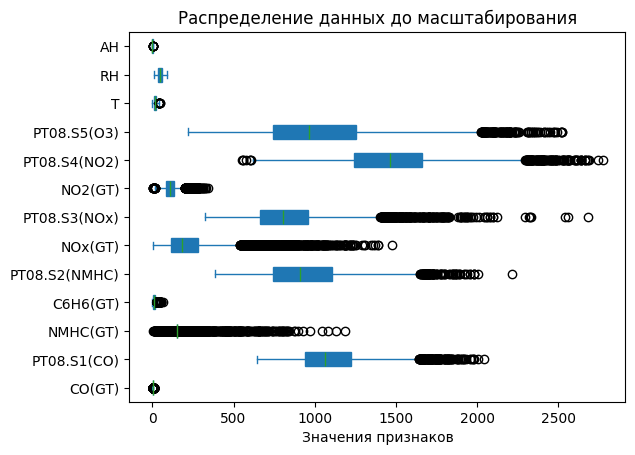

In [14]:
# Выделим только числовые признаки (исключаем Date и Time)
numeric_cols = data_cleaned_v2.select_dtypes(include=['float64']).columns
numeric_data = data_cleaned_v2[numeric_cols].copy()

# Заполним оставшиеся пропуски медианными значениями
numeric_data = numeric_data.fillna(numeric_data.median())

print("Статистика до масштабирования:")
print(numeric_data.describe().round(2))

plt.figure(figsize=(15, 8))
numeric_data.plot(kind='box', vert=False, patch_artist=True)
plt.title('Распределение данных до масштабирования')
plt.xlabel('Значения признаков')
plt.show()

In [15]:
# Коэффициенты асимметрии (чем дальше от 0, тем более асимметрично)
print(numeric_data.skew().sort_values())

RH              -0.041220
PT08.S4(NO2)     0.207192
AH               0.265284
T                0.322536
PT08.S2(NMHC)    0.585917
PT08.S5(O3)      0.657515
NO2(GT)          0.732256
PT08.S1(CO)      0.789936
PT08.S3(NOx)     1.136738
C6H6(GT)         1.413328
CO(GT)           1.629331
NOx(GT)          2.014576
NMHC(GT)         6.895299
dtype: float64


Для линейной регрессии и Ridge-регрессии предпочтительна стандартизация

Стандартизированные данные лучше работают с регуляризацией

Почему StandardScaler, а не MinMaxScaler?
Присутствие выбросов:

На BoxPlot видно, что почти все признаки имеют значительные выбросы

MinMaxScaler сжимает все значения в диапазон [0, 1], что усилит влияние выбросов

StandardScaler сохраняет относительное положение выбросов благодаря z-score

Разный масштаб признаков:

PT08.S1(CO): ~647-2040 (масштаб тысяч)

NOx(GT): ~2-1479 (широкий диапазон)

RH: ~9.2-88.7 (десятки)

StandardScaler лучше справляется с такими различиями

In [16]:
from sklearn.preprocessing import StandardScaler

# Инициализация и применение
scaler = StandardScaler()
data_scaled = scaler.fit_transform(numeric_data)

# Добавление обратно в DataFrame
data_cleaned_v2[numeric_cols] = data_scaled

# Проверка
print("После StandardScaler:")
print(pd.DataFrame(data_cleaned_v2, columns=numeric_cols).describe().round(2))

После StandardScaler:
        CO(GT)  PT08.S1(CO)  NMHC(GT)  C6H6(GT)  PT08.S2(NMHC)  NOx(GT)  \
count  9357.00      9357.00   9357.00   9357.00        9357.00  9357.00   
mean      0.00         0.00     -0.00     -0.00           0.00     0.00   
std       1.00         1.00      1.00      1.00           1.00     1.00   
min      -1.50        -2.12     -2.23     -1.36          -2.12    -1.20   
25%      -0.67        -0.74     -0.10     -0.74          -0.75    -0.63   
50%      -0.22        -0.17     -0.10     -0.25          -0.11    -0.28   
75%       0.39         0.58     -0.10      0.49           0.64     0.25   
max       7.42         4.42     15.39      7.34           4.88     6.38   

       PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)        T       RH  \
count       9357.00  9357.00       9357.00      9357.00  9357.00  9357.00   
mean           0.00    -0.00          0.00        -0.00     0.00     0.00   
std            1.00     1.00          1.00         1.00     1.00     1.

<Figure size 1500x600 with 0 Axes>

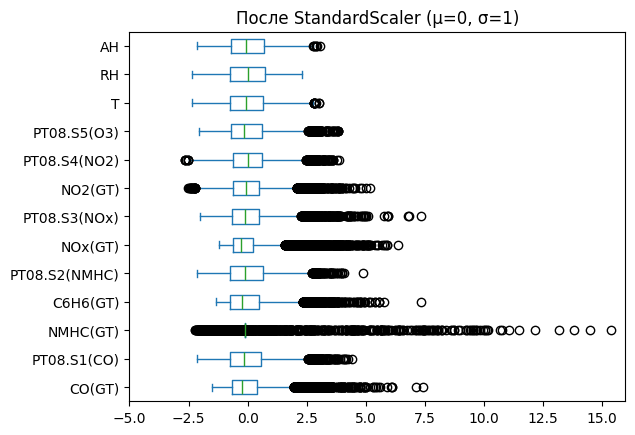

In [17]:
plt.figure(figsize=(15,6))
pd.DataFrame(scaler.fit_transform(numeric_data), columns=numeric_data.columns)\
  .plot(kind='box', vert=False)
plt.title('После StandardScaler (μ=0, σ=1)')
plt.xlim(-5, 16)
plt.show()

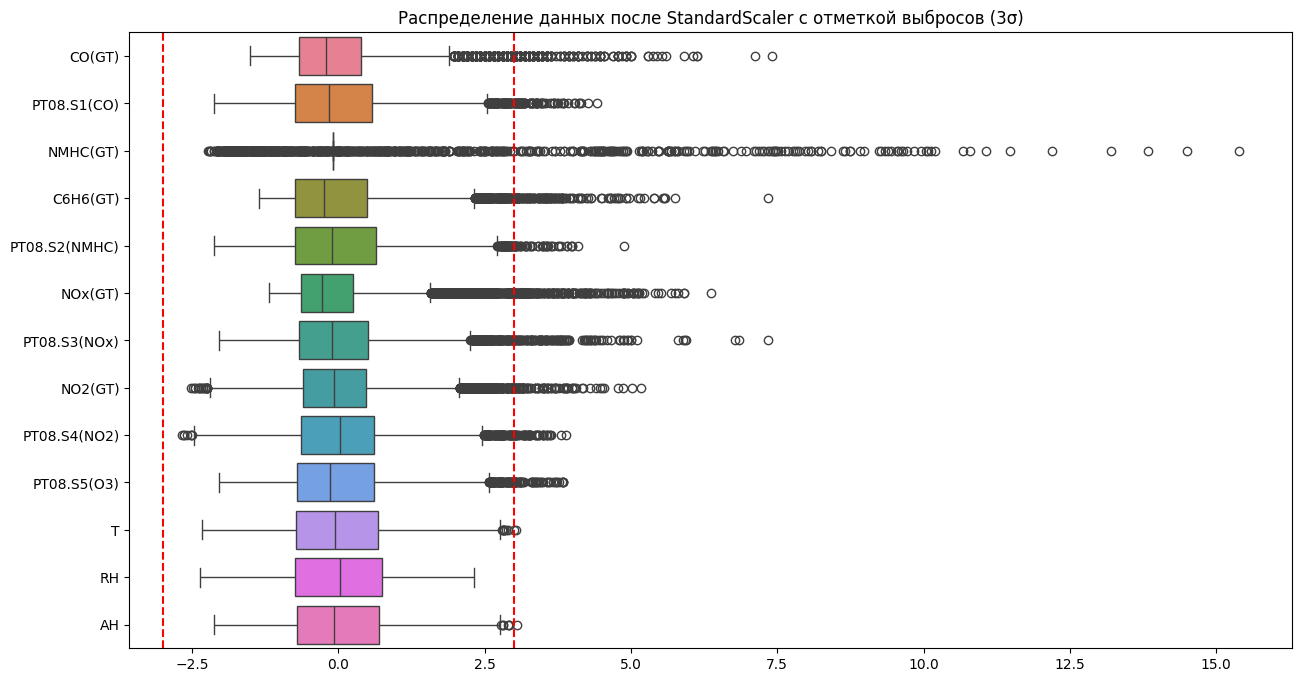

In [18]:
plt.figure(figsize=(15, 8))
sns.boxplot(data=data_cleaned_v2, orient='h')
plt.axvline(x=3, color='r', linestyle='--')
plt.axvline(x=-3, color='r', linestyle='--')
plt.title('Распределение данных после StandardScaler с отметкой выбросов (3σ)')
plt.show()

Типы колонок в итоговом DataFrame:
Date              object
Time              object
CO(GT)           float64
PT08.S1(CO)      float64
NMHC(GT)         float64
C6H6(GT)         float64
PT08.S2(NMHC)    float64
NOx(GT)          float64
PT08.S3(NOx)     float64
NO2(GT)          float64
PT08.S4(NO2)     float64
PT08.S5(O3)      float64
T                float64
RH               float64
AH               float64
dtype: object
Удалено строк с выбросами: 665
Осталось строк: 8692

Статистика после удаления:
        CO(GT)  PT08.S1(CO)  NMHC(GT)  C6H6(GT)  PT08.S2(NMHC)  NOx(GT)  \
count  8692.00      8692.00   8692.00   8692.00        8692.00  8692.00   
mean     -0.13        -0.10     -0.11     -0.11          -0.09    -0.11   
std       0.79         0.87      0.38      0.83           0.89     0.79   
min      -1.50        -2.03     -2.17     -1.33          -2.01    -1.20   
25%      -0.67        -0.75     -0.10     -0.75          -0.77    -0.65   
50%      -0.22        -0.18     -0.10     -0.2

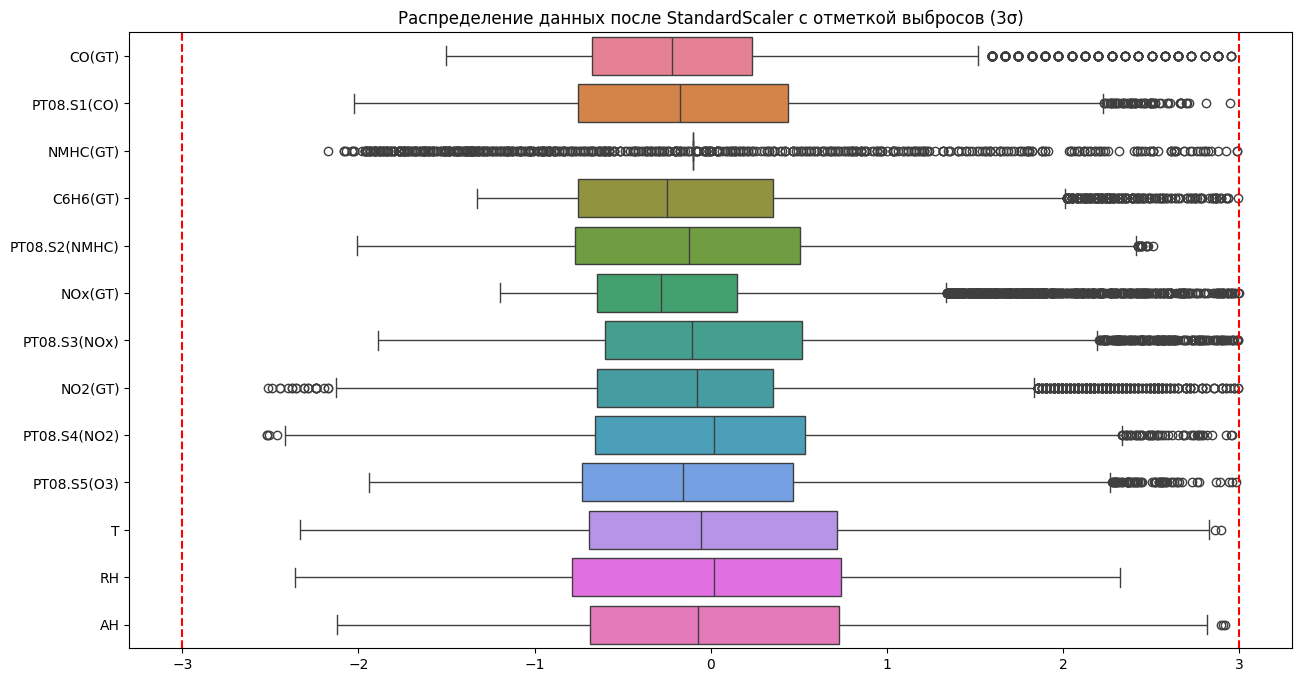

In [19]:
# 1. Разделяем данные
numeric_cols = data_cleaned_v2.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = data_cleaned_v2[['Date', 'Time']]

# 2. Создаем копию DataFrame
data_filtered = data_cleaned_v2.copy()

# 3. Создаем маску выбросов (для строк)
outliers_mask = (np.abs(data_cleaned_v2[numeric_cols]) > 3).any(axis=1)

# 4. Фильтруем числовые данные
filtered_numeric = data_cleaned_v2[numeric_cols][~outliers_mask]

# 5. Фильтруем категориальные данные
filtered_categorical = data_cleaned_v2[['Date', 'Time']][~outliers_mask]

# 6. Объединяем обратно
data_filtered = pd.concat([filtered_categorical, filtered_numeric], axis=1)

# 7. Проверяем колонки
print("Типы колонок в итоговом DataFrame:")
print(data_filtered.dtypes)

# 8. Проверяем выбросы
print(f"Удалено строк с выбросами: {outliers_mask.sum()}")
print(f"Осталось строк: {len(data_filtered)}")
print("\nСтатистика после удаления:")
print(data_filtered[numeric_cols].describe().round(2))

plt.figure(figsize=(15, 8))
sns.boxplot(data=data_filtered, orient='h')
plt.axvline(x=3, color='r', linestyle='--')
plt.axvline(x=-3, color='r', linestyle='--')
plt.title('Распределение данных после StandardScaler с отметкой выбросов (3σ)')
plt.show()

Убрали выбросы из числовых(количественных) данных

In [20]:
data_filtered.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,0.386029,1.228781,-0.100241,0.258577,0.412925,-0.354617,0.880318,0.014261,0.693887,0.633214,-0.542585,-0.020532,-0.673353
1,10/03/2004,19.00.00,-0.067502,0.909382,-0.666943,-0.083356,0.065082,-0.677560,1.348952,-0.463597,0.301964,-0.124277,-0.577236,-0.091228,-0.754948
2,10/03/2004,20.00.00,0.083675,1.426057,-1.024861,-0.138065,0.003922,-0.534030,1.213922,0.037016,0.290176,0.136750,-0.738941,0.279927,-0.692552
3,10/03/2004,21.00.00,0.083675,1.303934,-1.144167,-0.110711,0.038324,-0.323861,1.023291,0.219057,0.375633,0.466873,-0.842894,0.633408,-0.600347
4,10/03/2004,22.00.00,-0.369856,0.815441,-1.576650,-0.479998,-0.389791,-0.534030,1.472068,0.082526,0.098635,0.228878,-0.819793,0.609842,-0.595042


Так все отлично получается числовые данные почищены, отскелины, переходим к замене категориальных признаков

Обоснование выбора методов:
Почему не One-Hot Encoding?

Для даты: создаст дофига новых колонок (неэффективно)

Для времени: потеряет циклическую природу данных

Почему не Label Encoding?

Для даты: создаст ложные порядковые отношения, типа (01/01 < 02/01)

Для времени: аналогичная проблема с циклической природой

Почему выбранные методы лучше:

Для даты:

Разложение на год/месяц/день сохраняет информацию

Не создает избыточных признаков

Позволяет моделям выявлять сезонные закономерности

Для времени:

Циклическое кодирование (sin/cos) сохраняет:

Близость 23:00 и 00:00

Периодическую природу времени

In [21]:
from sklearn.preprocessing import MinMaxScaler


# Создаем копию DataFrame
data_filtered_v1 = data_filtered.copy()

# 1. Преобразование даты
data_filtered_v1['Date'] = pd.to_datetime(data_filtered_v1['Date'], format='%d/%m/%Y')
data_filtered_v1['Year'] = data_filtered_v1['Date'].dt.year - 2003  # Нормализация года
data_filtered_v1['Month'] = data_filtered_v1['Date'].dt.month
data_filtered_v1['Day'] = data_filtered_v1['Date'].dt.day

# 2. Преобразование времени
def time_to_cyclic(time_str):
    try:
        time_obj = pd.to_datetime(time_str, format='%H.%M.%S').time()
        return [
            np.sin(2*np.pi*time_obj.hour/24),
            np.cos(2*np.pi*time_obj.hour/24)
        ]
    except:
        return [np.nan, np.nan]

time_cyclic = pd.DataFrame(
    data_filtered_v1['Time'].apply(time_to_cyclic).tolist(),
    columns=['Hour_sin', 'Hour_cos'],
    index=data_filtered_v1.index
)

# 3. Преобразование месяца и дня
data_filtered_v1['Month_sin'] = np.sin(2*np.pi*(data_filtered_v1['Month']-1)/12)
data_filtered_v1['Month_cos'] = np.cos(2*np.pi*(data_filtered_v1['Month']-1)/12)

days_in_month = data_filtered_v1['Date'].dt.daysinmonth
data_filtered_v1['Day_norm'] = (data_filtered_v1['Day']-1)/(days_in_month-1)

# 4. Объединяем все признаки
data_processed = pd.concat([
    data_filtered_v1.drop(['Date', 'Time', 'Month', 'Day'], axis=1),
    time_cyclic
], axis=1)

# 5. Масштабируем циклические признаки
scaler = MinMaxScaler()
cyclic_cols = ['Hour_sin', 'Hour_cos', 'Month_sin', 'Month_cos']
data_processed[cyclic_cols] = scaler.fit_transform(data_processed[cyclic_cols])

# Проверка
print("Типы признаков после преобразования:")
print(data_processed.dtypes)
data_processed.head()

Типы признаков после преобразования:
CO(GT)           float64
PT08.S1(CO)      float64
NMHC(GT)         float64
C6H6(GT)         float64
PT08.S2(NMHC)    float64
NOx(GT)          float64
PT08.S3(NOx)     float64
NO2(GT)          float64
PT08.S4(NO2)     float64
PT08.S5(O3)      float64
T                float64
RH               float64
AH               float64
Year               int32
Month_sin        float64
Month_cos        float64
Day_norm         float64
Hour_sin         float64
Hour_cos         float64
dtype: object


,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Year,Month_sin,Month_cos,Day_norm,Hour_sin,Hour_cos
0,0.386029,1.228781,-0.100241,0.258577,0.412925,-0.354617,0.880318,0.014261,0.693887,0.633214,-0.542585,-0.020532,-0.673353,1,0.933013,0.75,0.3,0.000000,0.500000
1,-0.067502,0.909382,-0.666943,-0.083356,0.065082,-0.677560,1.348952,-0.463597,0.301964,-0.124277,-0.577236,-0.091228,-0.754948,1,0.933013,0.75,0.3,0.017037,0.629410
2,0.083675,1.426057,-1.024861,-0.138065,0.003922,-0.534030,1.213922,0.037016,0.290176,0.136750,-0.738941,0.279927,-0.692552,1,0.933013,0.75,0.3,0.066987,0.750000
3,0.083675,1.303934,-1.144167,-0.110711,0.038324,-0.323861,1.023291,0.219057,0.375633,0.466873,-0.842894,0.633408,-0.600347,1,0.933013,0.75,0.3,0.146447,0.853553
4,-0.369856,0.815441,-1.576650,-0.479998,-0.389791,-0.534030,1.472068,0.082526,0.098635,0.228878,-0.819793,0.609842,-0.595042,1,0.933013,0.75,0.3,0.250000,0.933013


Получим DataFrame полностью с числовыми признаками, где:

1. Год (Year):

В данных только 2004-2005 годы

Не масштабируйте - это категориальный признак с малым количеством уникальных значений

Лучше оставить как есть или преобразовать в относительный год (0 для 2004, 1 для 2005)

2. Месяц (Month):

Циклический признак (12 → 1)

3. День (Day):

Полуциклический признак (зависит от месяца)

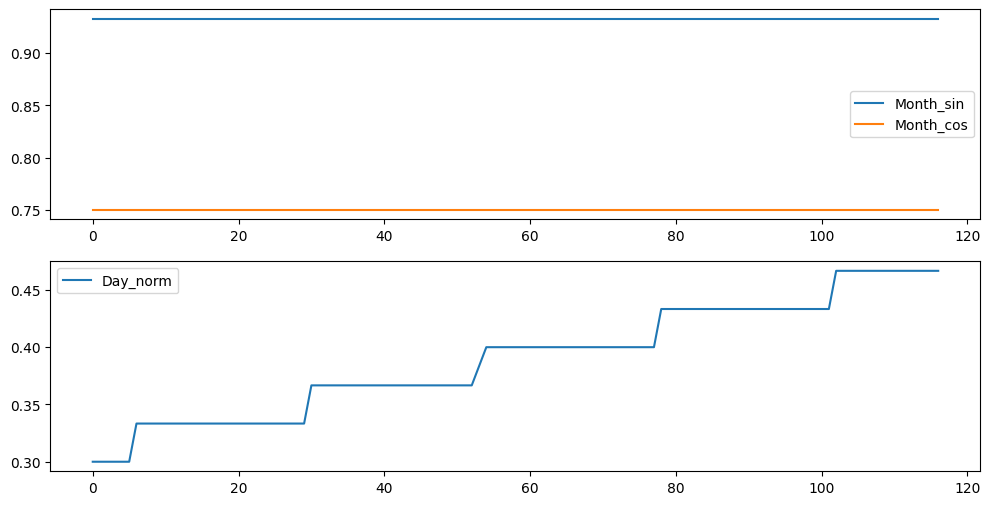

In [22]:
plt.figure(figsize=(12, 6))
plt.subplot(2,1,1)
plt.plot(data_processed['Month_sin'][:100], label='Month_sin')
plt.plot(data_processed['Month_cos'][:100], label='Month_cos')
plt.legend()

plt.subplot(2,1,2)
plt.plot(data_processed['Day_norm'][:100], label='Day_norm')
plt.legend()
plt.show()

Графики подтверждают, что:

Временные зависимости сохранены

Нет артефактов масштабирования

Данные готовы для анализа в моделях

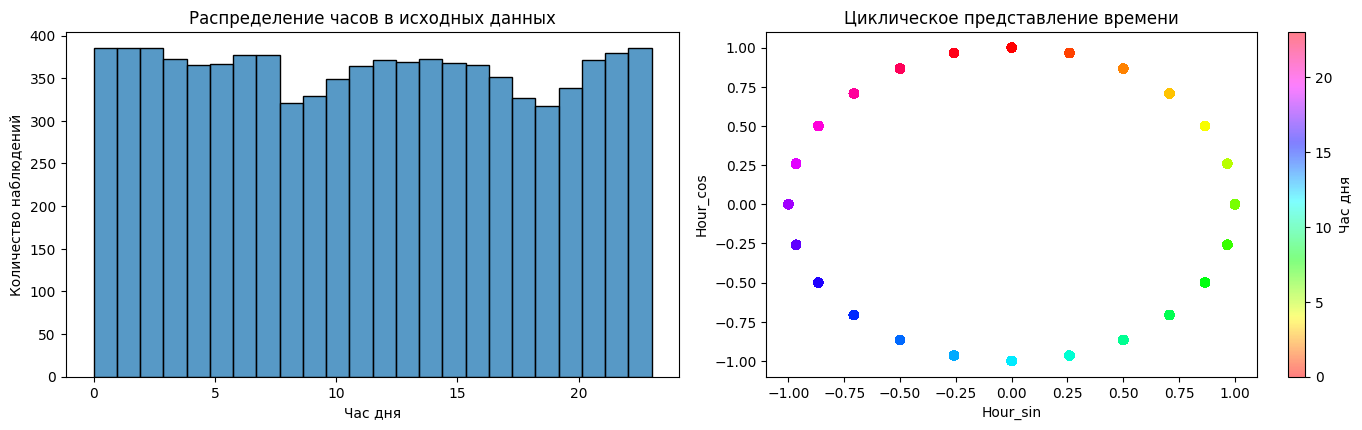

In [23]:
# 1. Визуализация распределения часов
plt.figure(figsize=(14, 8))

# Гистограмма исходных часов
hours = data_filtered_v1['Time'].apply(lambda x: pd.to_datetime(x, format='%H.%M.%S').hour)
plt.subplot(2, 2, 1)
sns.histplot(hours, bins=24, kde=False)
plt.title('Распределение часов в исходных данных')
plt.xlabel('Час дня')
plt.ylabel('Количество наблюдений')

# 2. Визуализация циклических координат
plt.subplot(2, 2, 2)
plt.scatter(time_cyclic['Hour_sin'], time_cyclic['Hour_cos'], 
            c=hours, cmap='hsv', alpha=0.5)
plt.colorbar(label='Час дня')
plt.title('Циклическое представление времени')
plt.xlabel('Hour_sin')
plt.ylabel('Hour_cos')

plt.tight_layout()
plt.show()

Графики подтверждают, что:

Преобразование времени выполнено технически правильно

Есть содержательные временные паттерны для анализа

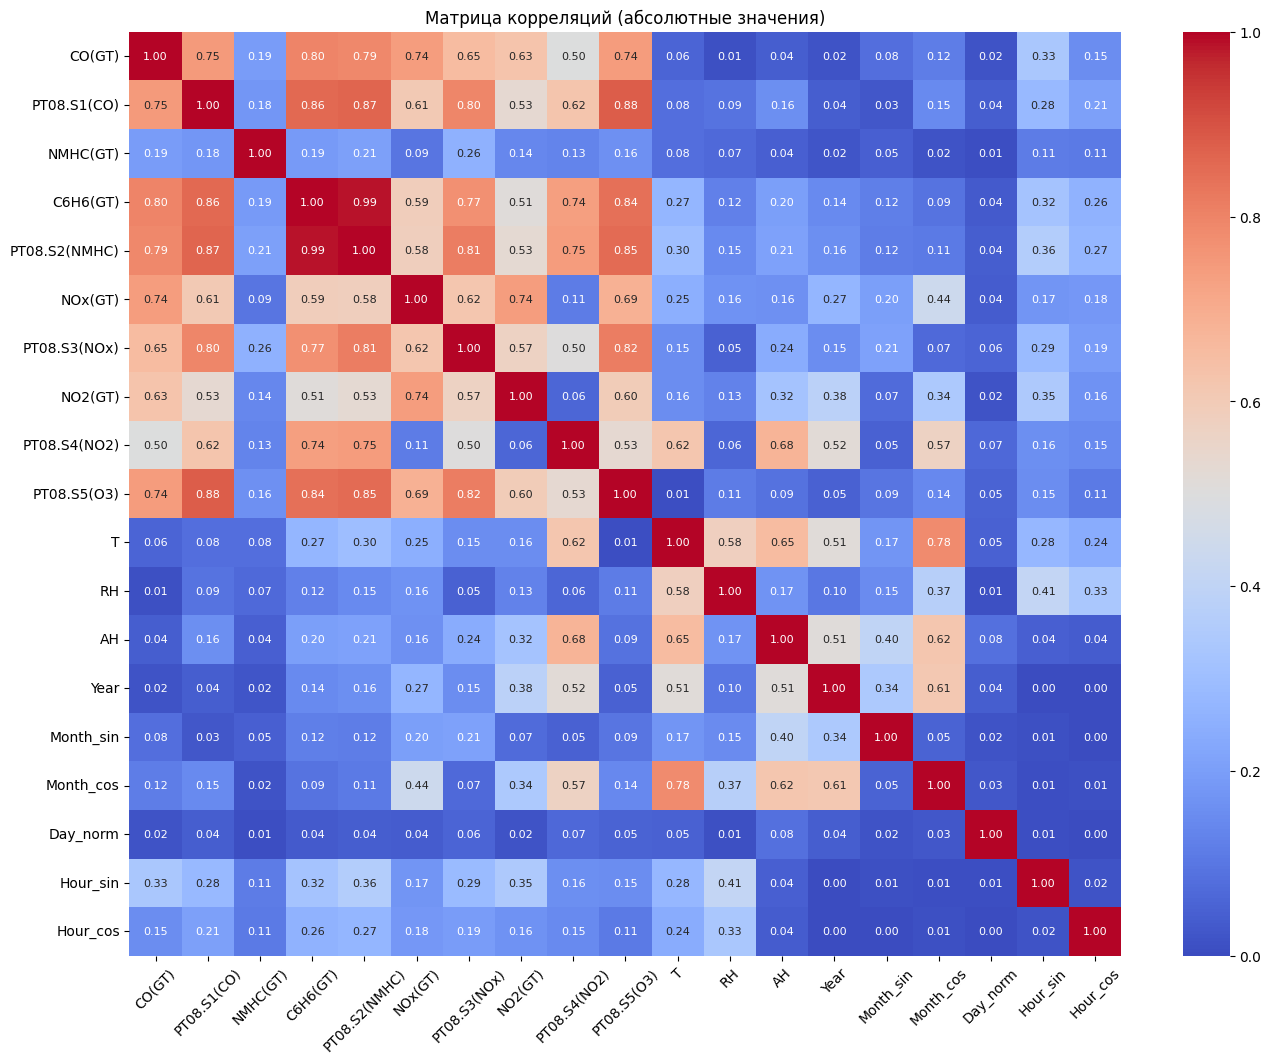

In [24]:
# Выбираем только числовые колонки
numeric_cols = data_processed.select_dtypes(include=['float64', 'int32']).columns

# Строим матрицу корреляций
corr_matrix = data_processed[numeric_cols].corr().abs()  # Берем абсолютные значения

# Визуализация
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', 
            annot_kws={"size": 8}, vmin=0, vmax=1)
plt.title('Матрица корреляций (абсолютные значения)')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

Оставшиеся признаки: ['CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']


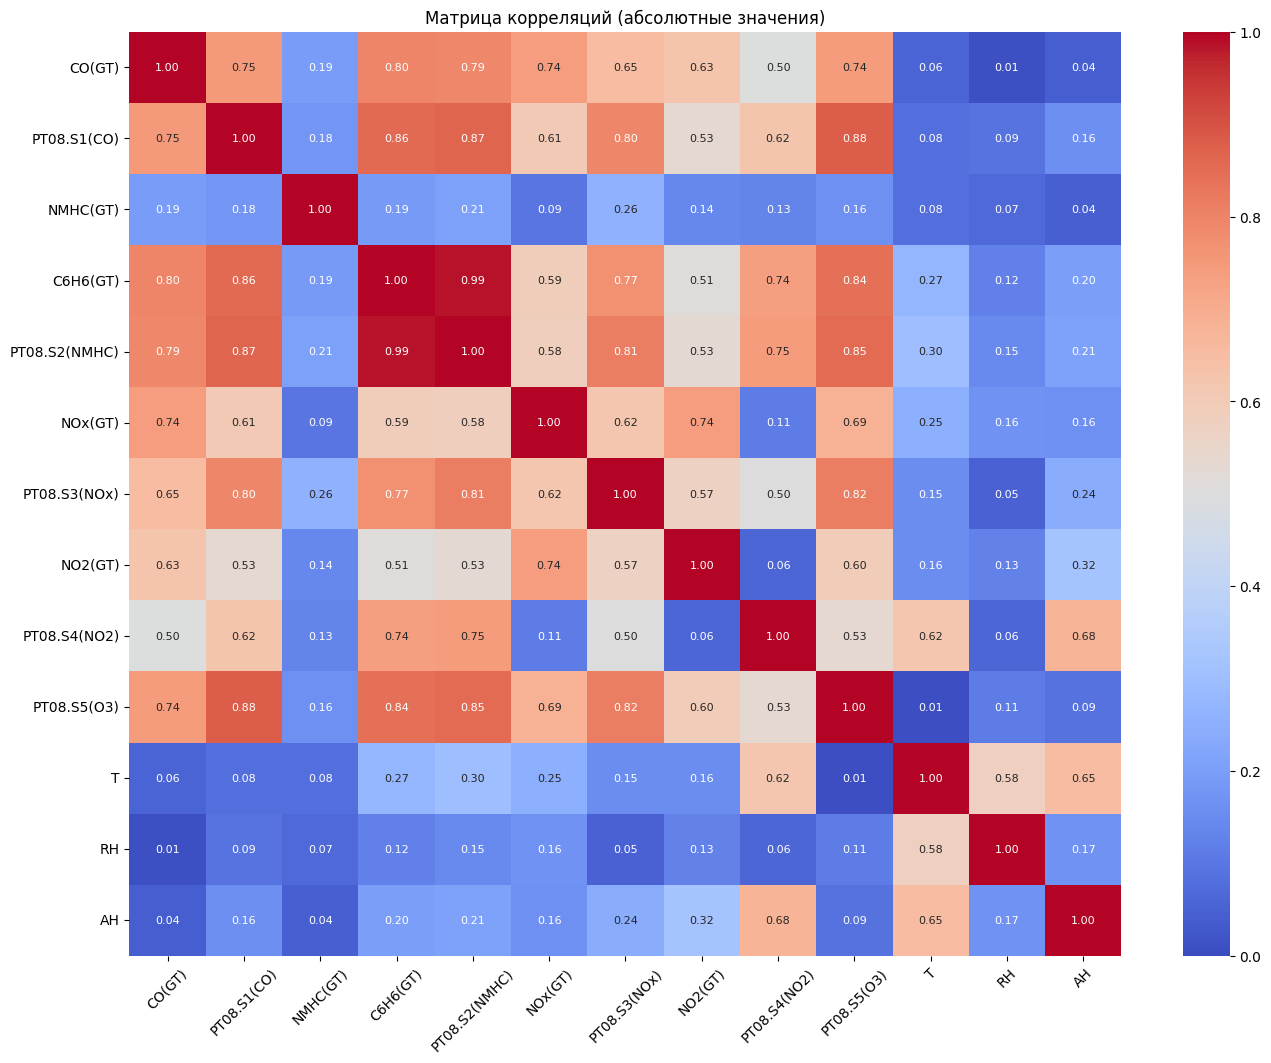

In [25]:
# Дропаем ненужные столбцы(со слабой корреляцией)
data_processed_drop = data_processed.drop(columns=["Year", "Month_sin", "Month_cos", "Day_norm","Hour_sin","Hour_cos"])
print("Оставшиеся признаки:", list(data_processed_drop.columns))

# Выбираем только числовые колонки
numeric_cols = data_processed_drop.select_dtypes(include=['float64', 'int32']).columns

# Строим матрицу корреляций
corr_matrix = data_processed_drop[numeric_cols].corr().abs()  # Берем абсолютные значения

# Визуализация
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', 
            annot_kws={"size": 8}, vmin=0, vmax=1)
plt.title('Матрица корреляций (абсолютные значения)')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

1. Обычная линейная регрессия (без регуляризации)
Как работает:

Старается точно подогнать данные, но чувствительна к мультиколлинеарности и выбросам.

Важные признаки — те, у которых высокие абсолютные значения коэффициентов.

Рекомендуемые признаки:

PT08.S2(NMHC) (корр. с CO(GT) = 0.79)

C6H6(GT) (корр. = 0.80, но дублирует PT08.S2 — оставим один)

PT08.S5(O3) (корр. = 0.74)

NOX(GT) (корр. = 0.74)

PT08.S3(NOX) (корр. = 0.65)

Проблемы:

Если оставить C6H6(GT) и PT08.S2(NMHC) (корр. между ними = 0.99), модель станет неустойчивой.

Признаки с низкой корреляцией (например, T, RH) добавят шум.

Решение:

Удалить мультиколлинеарные (C6H6(GT), оставляем PT08.S2(NMHC)).

Удалить слабые (RH, AH, NMHC(GT)).

2. Ridge-регрессия (L2-регуляризация)
Как работает:

Штрафует большие коэффициенты, уменьшая влияние мультиколлинеарности.

Признаки с умеренной корреляцией могут сохранить значимость.

Рекомендуемые признаки:

PT08.S2(NMHC) (сильная связь с CO(GT), но Ridge "усреднит" его с C6H6(GT))

PT08.S5(O3) (корр. = 0.74)

NOX(GT) (корр. = 0.74)

PT08.S3(NOX) (корр. = 0.65)

PT08.S4(NO2) (корр. = 0.50, но Ridge может усилить его роль)

Плюсы Ridge:

Можно оставить оба коррелирующих признака (например, C6H6(GT) и PT08.S2(NMHC)), так как регуляризация снизит их коэффициенты.

Менее чувствительна к шуму, поэтому можно оставить T (температуру).

Сравнение подходов
Признак	Корр. с CO(GT)	Линейная (без регуляризации)  Ridge (L2)
PT08.S2(NMHC)	0.79	✅ Высокий коэффициент	      ✅ Умеренный
C6H6(GT)	    0.80	❌ Удалить (коллинеарность)	  ✅ Оставить
PT08.S5(O3)	    0.74	✅ Важный	                  ✅ Важный
NOX(GT)	        0.74	✅ Важный	                  ✅ Важный
PT08.S3(NOX)	0.65	✅ Средняя важность	          ✅ Средняя
PT08.S4(NO2)	0.50	❌ Слабый	                  ✅ Возможно
T (температура)	0.06	❌ Удалить	                  ✅ Оставить

Оставшиеся признаки: ['CO(GT)', 'PT08.S1(CO)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S5(O3)']


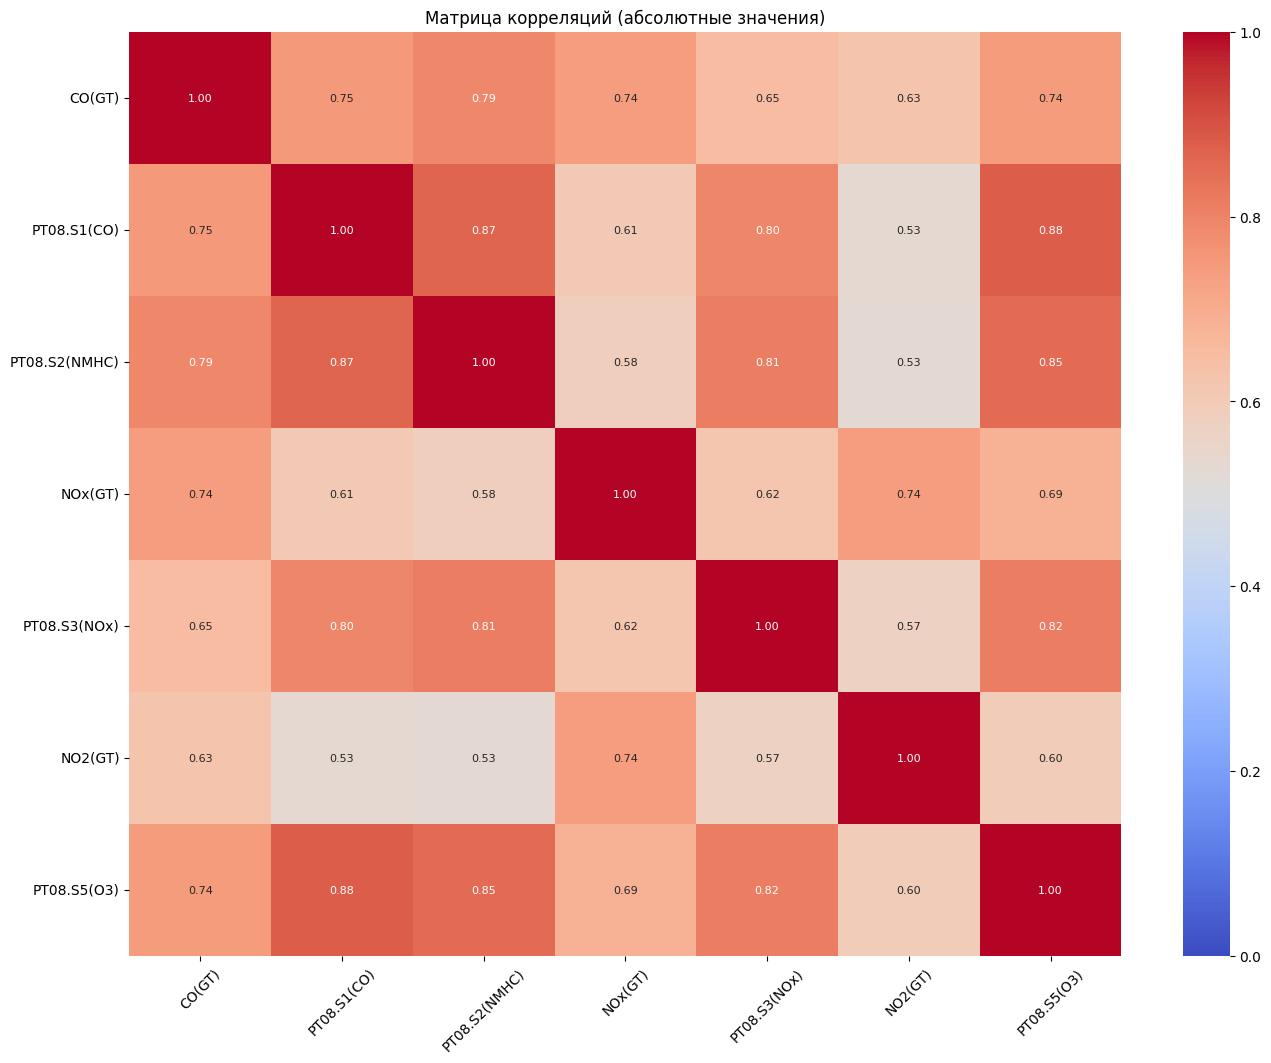

In [32]:
# Для линейной без регуляризации удаляем соответствующие признаки
data_processed_drop_v1 = data_processed.copy()
data_processed_drop_v1 = data_processed.drop(columns=["T","PT08.S4(NO2)", "NMHC(GT)","C6H6(GT)","RH", "AH", "Year", "Month_sin", "Month_cos", "Day_norm","Hour_sin","Hour_cos"])
print("Оставшиеся признаки:", list(data_processed_drop_v1.columns))

# Выбираем только числовые колонки
numeric_cols = data_processed_drop_v1.select_dtypes(include=['float64', 'int32']).columns

# Строим матрицу корреляций
corr_matrix = data_processed_drop_v1[numeric_cols].corr().abs()  # Берем абсолютные значения

# Визуализация
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', 
            annot_kws={"size": 8}, vmin=0, vmax=1)
plt.title('Матрица корреляций (абсолютные значения)')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

In [43]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
import scipy.stats as stats


data_processed_drop_v2 = data_processed_drop_v1.copy()
data_processed_drop_v2.dtypes

CO(GT)           float64
PT08.S1(CO)      float64
PT08.S2(NMHC)    float64
NOx(GT)          float64
PT08.S3(NOx)     float64
NO2(GT)          float64
PT08.S5(O3)      float64
dtype: object

In [44]:
# Разделение на признаки (X) и целевую переменную (y)
X = data_processed_drop_v1.drop(columns=['CO(GT)'])  # Все признаки, кроме целевого
y = data_processed_drop_v1['CO(GT)']  # Целевая переменная

# Разделение на обучающую и тестовую выборки (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

R² на кросс-валидации: 0.760 ± 0.011

Результаты Linear Regression:
- MSE: 0.1526
- R²: 0.7559
- MAE: 0.2753
- RMSE: 0.3906
- Median Absolute Error: 0.1904

Корреляции:
Pearson: r = 0.869, p-value = 0.0000
Spearman: r = 0.846, p-value = 0.0000


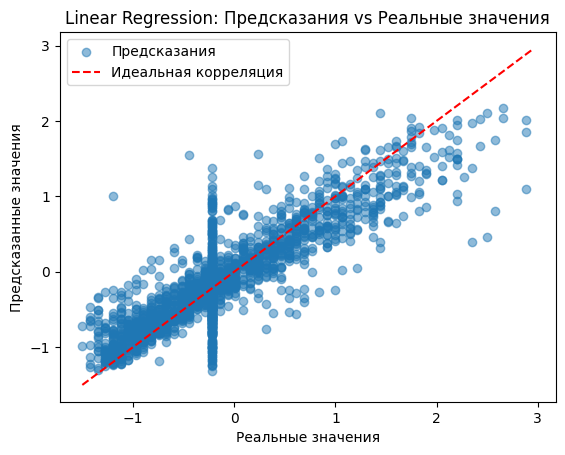

In [48]:
from sklearn.metrics import mean_absolute_error, median_absolute_error
from sklearn.model_selection import train_test_split, cross_val_score
from scipy.stats import pearsonr, spearmanr


# --- 1. Линейная регрессия без регуляризации ---
lr = LinearRegression()

# Кросс-валидация на обучающей выборке (5 фолдов)
cv_scores = cross_val_score(lr, X_train, y_train, cv=5, scoring='r2')
print(f"R² на кросс-валидации: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

# Обучение модели на всей обучающей выборке
lr.fit(X_train, y_train)

# Предсказание на тесте
y_pred = lr.predict(X_test)

# --- 2. Оценка точности ---
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
medae = median_absolute_error(y_test, y_pred)

print("\nРезультаты Linear Regression:")
print(f"- MSE: {mse:.4f}")
print(f"- R²: {r2:.4f}")
print(f"- MAE: {mae:.4f}")
print(f"- RMSE: {rmse:.4f}")
print(f"- Median Absolute Error: {medae:.4f}")

# --- 3. Корреляции и p-value ---
pearson_corr, pearson_p = pearsonr(y_test, y_pred)
spearman_corr, spearman_p = spearmanr(y_test, y_pred)

print("\nКорреляции:")
print(f"Pearson: r = {pearson_corr:.3f}, p-value = {pearson_p:.4f}")
print(f"Spearman: r = {spearman_corr:.3f}, p-value = {spearman_p:.4f}")

# --- 4. Визуализация ---
plt.scatter(y_test, y_pred, alpha=0.5, label='Предсказания')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='Идеальная корреляция')
plt.xlabel("Реальные значения")
plt.ylabel("Предсказанные значения")
plt.legend()
plt.title("Linear Regression: Предсказания vs Реальные значения")
plt.show()

1. Качество модели (метрики)
R² на кросс-валидации: 0.760 ± 0.011

Интерпретация: Модель объясняет ~76% дисперсии данных. Небольшое стандартное отклонение (±0.011) указывает на устойчивость результатов при кросс-валидации.

Оценка: Хороший результат для линейной модели (R² > 0.7 считается приемлемым).

R² на тестовой выборке: 0.7559

Почти идентичен кросс-валидационному R², что говорит об отсутствии переобучения.

MSE: 0.1526, RMSE: 0.3906

RMSE показывает среднюю ошибку в единицах целевой переменной. CO(GT) измеряется в мг/м³, ошибка составляет ~0.39 мг/м³.
Хороший результат для экологических данных, где много шума и внешних факторов.

MAE: 0.2753, Median Absolute Error: 0.1904

Медианная ошибка (0.19) меньше средней (0.27), значит, есть немного выбросов с большими ошибками.

2. Корреляции и p-value
Pearson (r = 0.869, p-value = 0.0000)

Сильная линейная зависимость между предсказанными и реальными значениями.

p-value ≈ 0 означает, что корреляция статистически значима.

Spearman (r = 0.846, p-value = 0.0000)

Монотонная зависимость также сильная, но немного слабее линейной.

Перейдем к линейной регрессии с RIDGE регуляризатором

In [49]:
data_processed.dtypes

CO(GT)           float64
PT08.S1(CO)      float64
NMHC(GT)         float64
C6H6(GT)         float64
PT08.S2(NMHC)    float64
NOx(GT)          float64
PT08.S3(NOx)     float64
NO2(GT)          float64
PT08.S4(NO2)     float64
PT08.S5(O3)      float64
T                float64
RH               float64
AH               float64
Year               int32
Month_sin        float64
Month_cos        float64
Day_norm         float64
Hour_sin         float64
Hour_cos         float64
dtype: object

In [50]:
data_processed_drop_ridge = data_processed.drop(columns=["Year", "Month_sin", "Month_cos", "Day_norm","Hour_sin","Hour_cos"])
print("Оставшиеся признаки:", list(data_processed_drop_ridge.columns))

Оставшиеся признаки: ['CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']


Лучшие параметры: {'alpha': 1, 'solver': 'svd'}

Результаты Ridge Regression:
- MSE: 0.1451
- R²: 0.7679
- MAE: 0.2645
- RMSE: 0.3809
- Median Absolute Error: 0.1769

Корреляции:
Pearson: r = 0.876, p-value = 0.0000
Spearman: r = 0.852, p-value = 0.0000


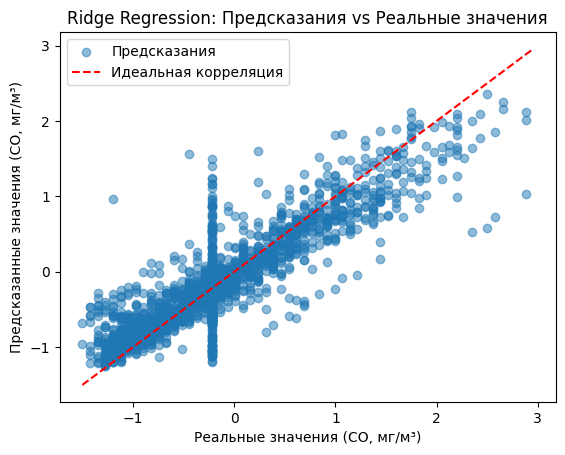


Важность признаков:
          Признак  Коэффициент
4         NOx(GT)     0.466486
2        C6H6(GT)     0.328492
7    PT08.S4(NO2)     0.273792
1        NMHC(GT)     0.132815
6         NO2(GT)     0.100444
0     PT08.S1(CO)     0.087539
5    PT08.S3(NOx)     0.078837
8     PT08.S5(O3)    -0.077890
9               T    -0.062424
11             AH    -0.041678
3   PT08.S2(NMHC)    -0.038526
10             RH    -0.034024


In [51]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge


# Загрузка данных
data = data_processed_drop_ridge.copy()
X = data.drop(columns=['CO(GT)'])  # Признаки
y = data['CO(GT)']  # Целевая переменная (концентрация CO в мг/м³)

# Разделение на обучающую и тестовую выборки (80%/20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 1. Ridge-регрессия с GridSearchCV ---
# Параметры для перебора
param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100],  # Сила регуляризации
    'solver': ['auto', 'svd', 'cholesky', 'lsqr']  # Алгоритм оптимизации
}

# Создание модели и подбор параметров
ridge = Ridge()
grid_search = GridSearchCV(ridge, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

# Лучшая модель
best_ridge = grid_search.best_estimator_
print(f"Лучшие параметры: {grid_search.best_params_}")

# Предсказание на тестовой выборке
y_pred = best_ridge.predict(X_test)

# --- 2. Оценка точности ---
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
medae = median_absolute_error(y_test, y_pred)

print("\nРезультаты Ridge Regression:")
print(f"- MSE: {mse:.4f}")
print(f"- R²: {r2:.4f}")
print(f"- MAE: {mae:.4f}")
print(f"- RMSE: {rmse:.4f}")
print(f"- Median Absolute Error: {medae:.4f}")

# --- 3. Корреляции и p-value ---
pearson_corr, pearson_p = pearsonr(y_test, y_pred)
spearman_corr, spearman_p = spearmanr(y_test, y_pred)

print("\nКорреляции:")
print(f"Pearson: r = {pearson_corr:.3f}, p-value = {pearson_p:.4f}")
print(f"Spearman: r = {spearman_corr:.3f}, p-value = {spearman_p:.4f}")

# --- 4. Визуализация ---
plt.scatter(y_test, y_pred, alpha=0.5, label='Предсказания')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='Идеальная корреляция')
plt.xlabel("Реальные значения (CO, мг/м³)")
plt.ylabel("Предсказанные значения (CO, мг/м³)")
plt.legend()
plt.title("Ridge Regression: Предсказания vs Реальные значения")
plt.show()

# --- 5. Анализ коэффициентов модели ---
coef_df = pd.DataFrame({
    'Признак': X.columns,
    'Коэффициент': best_ridge.coef_
}).sort_values(by='Коэффициент', key=abs, ascending=False)

print("\nВажность признаков:")
print(coef_df)

По поводу параметров и методов обучения:

Перебираем все комбинации параметров из param_grid:

alpha (сила регуляризации L2): от слабой (0.001) до сильной (100).

solver (алгоритм обучения):

'svd' — точное решение через SVD (стабилен для любых данных).

'cholesky' — быстрый, но требует положительно определённых матриц.

'lsqr' — итеративный метод для больших данных.

Кросс-валидация (cv=5):

Данные делятся на 5 фолдов.

Для каждой комбинации параметров модель обучается на 4 фолдах и проверяется на 1 фолде (процесс повторяется 5 раз).

Метрика (scoring='neg_mean_squared_error'):

Оптимизируется отрицательный MSE (чем ближе к 0, тем лучше).

Используется отрицательное значение, т.к. GridSearchCV максимизирует метрику.

Результат: Лучшая комбинация параметров ({'alpha': 1, 'solver': 'svd'}).

alpha=1: Компромисс между уменьшением переобучения и сохранением информативности коэффициентов.

solver='svd': Стабильный выбор для данных среднего размера с возможной мультиколлинеарностью.

1. Качество модели (метрики)
R² = 0.768
Модель объясняет 76.8% дисперсии данных, что немного лучше, чем у обычной линейной регрессии (R²=0.756).
Интерпретация: Улучшение на 1.2% за счёт регуляризации, которая снизила переобучение.

RMSE = 0.381 мг/м³
Средняя ошибка предсказания уменьшилась с 0.391 (без регуляризации) до 0.381 мг/м³.
Контекст:

Для экологического мониторинга ошибка в ~0.38 мг/м³ приемлема (8% от ПДК).

Пиковые значения (например, 5 мг/м³) могут предсказываться с ошибкой до ±0.76 мг/м³ (2 * RMSE).

MAE = 0.265 мг/м³, Median AE = 0.177 мг/м³
Медианная ошибка значительно ниже средней, что указывает на редкие, но есть ошибки (выбросы).

2. Корреляции и статистическая значимость
Pearson (r = 0.876):
Сильная линейная зависимость. Улучшение с 0.869 (без регуляризации).

Spearman (r = 0.852):
Монотонная зависимость также усилилась.

p-value = 0.0000 для обеих корреляций:
Результаты статистически значимы.

3. Визуализация (график)
Точки близки к диагонали, но разброс увеличивается для высоких концентраций (>3 мг/м³), как и для линейной без регуляризаторов.

4. Важность признаков
Топ-3 признака, влияющих на концентрацию CO:

NOx(GT) (коэффициент: 0.467) — Оксиды азота.

C6H6(GT) (коэффициент: 0.328) — Бензол.

PT08.S4(NO2) (коэффициент: 0.274) — Датчик NO₂.

Отрицательное влияние:

PT08.S5(O3), T (температура), AH (абсолютная влажность) — снижают прогнозируемую концентрацию CO.

Интерпретация:

Высокие уровни NOx и C6H6 коррелируют с увеличением CO (типично для автомобильных выбросов).

Озон (O₃) и температура могут способствовать химическим реакциям, уменьшающим CO.

Ridge-регрессия с параметрами alpha=1, solver='svd' показала себя как устойчивая и точная модель для прогнозирования CO.

Можно точнее объяснить влияние каждого параметра на концентрацию CO:

Признак             (Единицы измерения)	Коэффициент	Физическая интерпретация
NOx                       (ppb)	          +0.466	Основной "партнер" CO в реакциях горения. Рост NOx на 1 ppb → +0.47 мг/м³ CO.
C6H6                     (µg/m³)	      +0.328	Бензол — маркер автомобильных выбросов. Коррелирует с CO как продукт неполного сгорания.
PT08.S4(NO2)            (усл. ед.)	      +0.274	Датчик NO₂ косвенно отражает выбросы от транспорта (где есть и CO).
NMHC                     (µg/m³)	      +0.133	Неметановые углеводороды — продукты горения, связаны с CO.
PT08.S1(CO)             (усл. ед.)	      +0.088	Датчик SnO₂ для CO, но менее точен, чем эталонный анализатор.
PT08.S5(O3)             (усл. ед.)	      -0.078	Озон окисляет CO до CO₂ → отрицательный коэффициент.
Температура               (°C)	          -0.062	При высокой температуре CO быстрее окисляется или рассеивается.
Абсолютная влажность     (г/м³)	          -0.042	Влажность может способствовать осаждению частиц с CO.